# Логистическая регрессия

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from pathlib import Path
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from research_utils.learning import grid_search, iteration_learning_score, get_top_n_info
from research_utils.plot import create_panel, plot_learning_curve, plot_complexity_and_accuracy, df_hist, df_scatter, series_hist, series_scatter
from research_utils.stats import agg_by_columns
from predictors.serialization import save_model
from predictors.feature_selection import ModelFeatureSelector
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

save = partial(save_model, models_dir)
train = pd.read_parquet("../data/processed/train.parquet")

## Подготовка данных
Логистическая модель:
- Чувствительна к выбросам.
- Чувствительна к мультиколлинеарности.
- Может переобучаться при очень высокой размерности

### Обработка мультиколлинеарных признаков

1. Оставляем: `text__long_sentences_proportion`. Убираем: `text__symbols_length`
2.  Оставляем: `text__type_token_ratio`. Убираем: `text__rare_words_proportion`, `text__normalized_shannon_entropy`
3.  Оставляем: `text__mean_words_length`. Убираем: `text__long_words_proportion`
4.  Оставляем: `text__lexicon_size`. Убираем: `text__lexical_diversity_per_sentence`
5.  Оставляем: `pos__index_of_formality_heylinger`. Убираем: `pos__index_of_formality`
6.  Оставляем: `pos__mean_usage_NOUN` и `pos__mean_usage_ADP`. Убираем: `pos__mean_usage_ADJ`

In [3]:
numeric_features = {
    'text__long_sentences_proportion', 
    'text__unpopular_words_proportion',
    'text__type_token_ratio',
    'text__mean_words_length',
    'text__lexicon_size',
    'entities__breadth_of_use_entities',
    'pos__mean_usage_NOUN', 
    'pos__mean_usage_PRON', 
    'pos__mean_usage_ADV',
    'pos__mean_usage_ADP', 
    'pos__mean_usage_SCONJ',
    'pos__mean_usage_CCONJ', 
    'pos__mean_usage_VERB',
    'pos__mean_usage_PROPN', 
    'pos__mean_usage_DET', 
    'pos__mean_usage_PART',
    "pos__ADJPOS_NOUN",
    "pos__PUNCT_SCONJ",
    "pos__ADP_ADJPOS",
    "pos__ADP_PRON",
    "pos__PUNCT_ADV",
    "pos__ADJPOS_PUNCT",
    "pos__PUNCT_CCONJ",
    'pos__index_of_formality_heylinger',
    'punct__breadth_of_use_puncts', 
    "punct__mean_usage_comma"
}
combo_features = { 
    "pos__pair_of_adv_per_sentence",
    "pos__mean_usage_AUX",
    "pos__mean_usage_NUM",
    "pos__PROPN_PUNCT",
    "pos__PUNCT_PRON",
    "punct__mean_usage_colon",
    "punct__mean_usage_question",
    "punct__mean_usage_openparen",
    "punct__mean_usage_closeparen",
    "punct__mean_usage_hyphen",
    "punct__mean_usage_exclamation",
    "entities__mean_usage_NUMBER",
    "entities__mean_usage_QUOTE",
    "entities__mean_usage_PUNCEM",
    "entities__mean_usage_ADDRESS",
}
typical_features = {
    'entities__mean_usage_MEAS_is_typical',
    'entities__mean_usage_ENUM_is_typical',
    'entities__mean_usage_FOREIGN_is_typical',
    'pos__breadth_of_use_pos_is_typical',
    'pos__index_of_formality_tuldava_is_typical',
    'entities__mean_usage_SMILE_is_typical',
    'entities__mean_usage_DATE_is_typical'
}
features = numeric_features | combo_features | typical_features
features_list = list(features) + [ f"{col}_used" for col in combo_features ]

In [4]:
def skew_analyze(series):
    result = { }
    
    statistic = series.skew()
    abs_statistic = abs(statistic)
    
    result['Коэффициент ассиметрии'] = statistic
    result['Степень ассиметрии'] = "Незначительный" if abs_statistic < 0.25 else "Умеренный" if abs_statistic <= 0.5 else "Сильный"
    
    return result

def noise_analyze(series, threshold=1.5):
    result = { }
    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - IQR * threshold
    upper_bound = Q3 + IQR * threshold
    
    result['Q1'] = Q1
    result['Q3'] = Q3
    result['IQR'] = IQR
    result['lower_bound'] = lower_bound
    result['upper_bound'] = upper_bound

    outliers = series[(series < lower_bound ) | (series > upper_bound )]
    
    result['outliers_len'] = len(outliers)
    result['normals_len'] = len(series) - len(outliers)
    return result


In [5]:
skewness = agg_by_columns(train, list(numeric_features.union(combo_features)), skew_analyze)

In [6]:
noises = agg_by_columns(train, list(numeric_features.union(combo_features)), noise_analyze)

In [7]:
feature_summary = pd.concat([noises, skewness], axis=1)
feature_summary.sort_values(by='Коэффициент ассиметрии', ascending=False)

,Q1,Q3,IQR,lower_bound,upper_bound,outliers_len,normals_len,Коэффициент ассиметрии,Степень ассиметрии
punct__mean_usage_closeparen,0.000000,0.125000,0.125000,-1.875000e-01,0.312500,525,9100,6.807373,Сильный
entities__mean_usage_PUNCEM,0.000000,0.083333,0.083333,-1.250000e-01,0.208333,728,8897,6.626867,Сильный
punct__mean_usage_colon,0.000000,0.104167,0.104167,-1.562500e-01,0.260417,372,9253,4.819351,Сильный
entities__mean_usage_ADDRESS,0.000000,0.068182,0.068182,-1.022727e-01,0.170455,784,8841,4.754695,Сильный
punct__mean_usage_exclamation,0.000000,0.076923,0.076923,-1.153846e-01,0.192308,669,8956,4.032383,Сильный
entities__mean_usage_NUMBER,0.000000,0.130435,0.130435,-1.956522e-01,0.326087,721,8904,3.589038,Сильный
punct__mean_usage_hyphen,0.000000,0.206349,0.206349,-3.095238e-01,0.515873,331,9294,2.834598,Сильный
entities__mean_usage_QUOTE,0.018182,0.153846,0.135664,-1.853147e-01,0.357343,454,9171,2.828029,Сильный
pos__mean_usage_PROPN,0.163265,0.542857,0.379592,-4.061224e-01,1.112245,456,9169,2.619761,Сильный
punct__mean_usage_openparen,0.000000,0.103448,0.103448,-1.551724e-01,0.258621,449,9176,2.601331,Сильный


Большинство признаков, за исключением некоторых, имеют умеренную или сильную положительную асимметрию . Это значит, что у большинства признаков распределение смещено влево: есть тексты с аномально высокими значениями признака

Для исправления распределений воспользуемся методом "Yeo-Johnson"

In [8]:
to_fix = numeric_features.union(combo_features).difference([
    "punct__breadth_of_use_puncts",
    "entities__breadth_of_use_entities",
    "pos__index_of_formality_heylinger",
    "text__type_token_ratio"
])
to_fix_list = list(to_fix)

In [9]:
transformer = PowerTransformer(method='yeo-johnson', standardize=False)
fixed_df = pd.DataFrame(transformer.fit_transform(train[to_fix_list]), columns=to_fix_list)

In [10]:
skewness_after = agg_by_columns(fixed_df, to_fix_list, skew_analyze)

In [11]:
pd.concat([skewness, skewness_after], axis=1).dropna()

,Коэффициент ассиметрии,Степень ассиметрии,Коэффициент ассиметрии,Степень ассиметрии
pos__ADJPOS_NOUN,0.433930,Умеренный,0.000219,Незначительный
pos__PUNCT_CCONJ,0.716474,Сильный,0.008002,Незначительный
pos__ADP_PRON,0.922549,Сильный,0.013673,Незначительный
punct__mean_usage_colon,4.819351,Сильный,0.296633,Умеренный
pos__mean_usage_NOUN,0.484555,Умеренный,-0.004753,Незначительный
pos__PUNCT_ADV,0.755267,Сильный,0.003815,Незначительный
punct__mean_usage_question,2.526519,Сильный,0.432783,Умеренный
pos__mean_usage_DET,0.874328,Сильный,0.008366,Незначительный
pos__PROPN_PUNCT,2.102468,Сильный,0.141613,Незначительный
entities__mean_usage_QUOTE,2.828029,Сильный,0.249474,Незначительный


In [12]:
fixed_noises_df = agg_by_columns(fixed_df, to_fix_list, noise_analyze)
fixed_noises_df.sort_values(by='outliers_len', ascending=False)

,Q1,Q3,IQR,lower_bound,upper_bound,outliers_len,normals_len
text__mean_words_length,0.744340,0.756577,0.012237,0.725984,0.774934,133,9492
pos__mean_usage_VERB,0.921205,1.216699,0.295494,0.477964,1.659940,119,9506
text__unpopular_words_proportion,0.161742,0.176993,0.015251,0.138866,0.199869,107,9518
pos__mean_usage_ADV,0.526186,0.766654,0.240468,0.165485,1.127355,90,9535
pos__mean_usage_PART,0.305124,0.490027,0.184903,0.027770,0.767380,76,9549
pos__mean_usage_CCONJ,0.351187,0.512264,0.161077,0.109572,0.753879,74,9551
pos__ADJPOS_NOUN,0.188863,0.271921,0.083058,0.064276,0.396507,70,9555
pos__mean_usage_PRON,0.462113,0.704079,0.241966,0.099164,1.067028,70,9555
punct__mean_usage_comma,0.620389,0.902932,0.282543,0.196576,1.326746,66,9559
pos__mean_usage_DET,0.211957,0.346195,0.134238,0.010601,0.547552,58,9567


Кол-во шумов (значение не входит в 1.5 межквартильный размах) по каждому признаку стало допустимым (около 1-2% по каждому признаку)

Таким образом, пайплайн модели выглядит так:
- Из данных отбираются только необходимые признаки
- Бинарные признаки масштабируются
- Непрерывные значения обрабатываются методом "yeo-johnson", масштабируются и отбираются через KBest
- Комбинированные значения обрабатываются методом "yeo-johnson" и масштабируются
- Предобработанные признаки идут на вход модели

In [13]:
solvers = [ 'liblinear' ]
penalties = [ 'l1', 'l2' ]
cs = [ 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 25, 50, 100 ]
n_numeric_features = [10, 13, 16, 18, 21, 'all']

pipeline_params = {
    'scale_and_select__numeric__select_kbest__k': n_numeric_features,
    'model__solver': solvers,
    'model__penalty': penalties,
    'model__C': cs,
    "model__random_state": [ 42 ]
}

numeric_fix_list = list(numeric_features.difference([
    "punct__breadth_of_use_puncts",
    "entities__breadth_of_use_entities",
    "pos__index_of_formality_heylinger",
    "text__type_token_ratio"
]))
combo_fix_list = list(combo_features)

def create_lr_pipeline(model_params=None):
    if not model_params:
        model_params = {}
    
    return Pipeline([
        ('get_features', ModelFeatureSelector(features_list)),
        ('power_transform', ColumnTransformer([
            ('numeric_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in numeric_fix_list if f in features_list]),
            ('combo_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in combo_fix_list if f in features_list]),
        ], remainder='passthrough')),
        
        ('scale_and_select', ColumnTransformer([
            ('binary', RobustScaler(), 
             [features_list.index(f) for f in typical_features if f in features_list]),
            ('numeric', Pipeline([
                ('scaler', RobustScaler()),
                ('select_kbest', SelectKBest(score_func=f_classif, k='all'))
            ]), [features_list.index(f) for f in numeric_features if f in features_list]),
            ('combo', RobustScaler(), 
             [features_list.index(f) for f in combo_features if f in features_list]),
        ], remainder='passthrough')),
        
        ('model', LogisticRegression(**model_params))
    ])

## Независимые модели

### Классификатор пола

In [14]:
gender_pipeline = create_lr_pipeline()

gender_gs = grid_search(gender_pipeline, pipeline_params, train, train['gender'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [15]:
gender_gs.best_params_, gender_gs.best_score_

({'model__C': 0.5,
  'model__penalty': 'l1',
  'model__random_state': 42,
  'model__solver': 'liblinear',
  'scale_and_select__numeric__select_kbest__k': 'all'},
 np.float64(0.6756363636363636))

In [16]:
gender_top_5_info = get_top_n_info(gender_gs, n=5)
gender_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__random_state,param_model__solver,param_scale_and_select__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
41,1.721075,0.115555,0.022408,0.002858,0.5,l1,42,liblinear,all,"{'model__C': 0.5, 'model__penalty': 'l1', 'mod...",0.682597,0.675325,0.669091,0.668571,0.682597,0.675636,0.006161,1
34,0.925382,0.036455,0.020379,0.003039,0.1,l2,42,liblinear,21,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.682078,0.674805,0.669091,0.667532,0.682597,0.675221,0.006298,2
47,0.969985,0.056543,0.019013,0.001082,0.5,l2,42,liblinear,all,"{'model__C': 0.5, 'model__penalty': 'l2', 'mod...",0.683636,0.673766,0.666494,0.669091,0.681039,0.674805,0.006628,3
38,1.354434,0.110308,0.031171,0.002745,0.5,l1,42,liblinear,16,"{'model__C': 0.5, 'model__penalty': 'l1', 'mod...",0.679481,0.675325,0.669610,0.668571,0.680000,0.674597,0.004791,4
35,0.949792,0.043960,0.024970,0.001633,0.1,l2,42,liblinear,all,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.682078,0.675325,0.666494,0.668571,0.680000,0.674494,0.006125,5


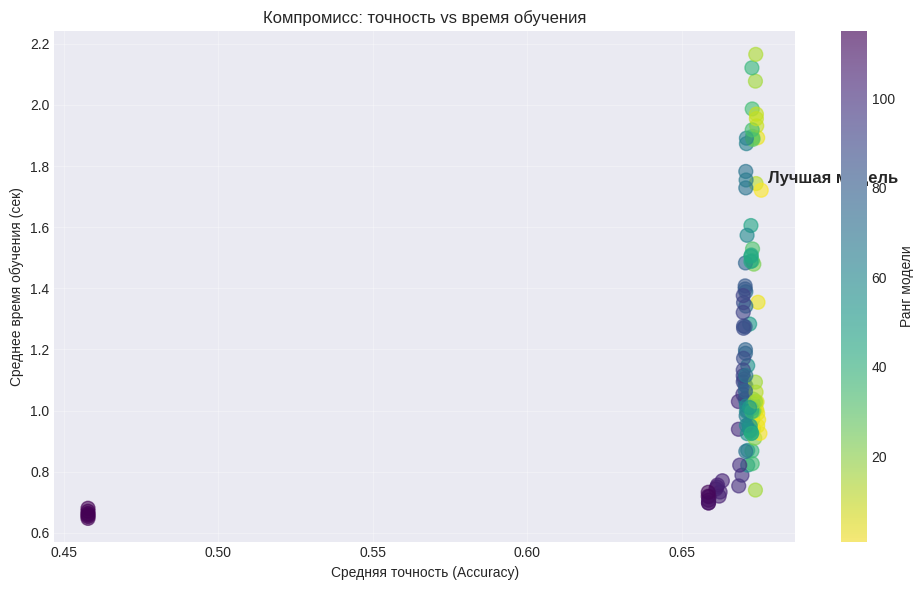

In [17]:
plot_complexity_and_accuracy(gender_gs)

In [18]:
gender_best_model_params = {
  'model__C': 0.5,
  'model__penalty': 'l1',
  'model__random_state': 42,
  'model__solver': 'liblinear',
  'scale_and_select__numeric__select_kbest__k': 'all'
}

gender_best_model = create_lr_pipeline()
gender_best_model.set_params(**gender_best_model_params)
gender_best_model_iter_learning_score = iteration_learning_score(gender_best_model, train, train['gender'])

In [20]:
alt_gender_model = create_lr_pipeline()
alt_gender_model.set_params(**
{
    'model__penalty': 'l2',          
    'model__C': 1000,                 
    'model__solver': 'liblinear',     
    'model__random_state': 42,        
    'scale_and_select__numeric__select_kbest__k': 10
}
)
alt_gender_model_iter_learning_score = iteration_learning_score(alt_gender_model, train, train['gender'])

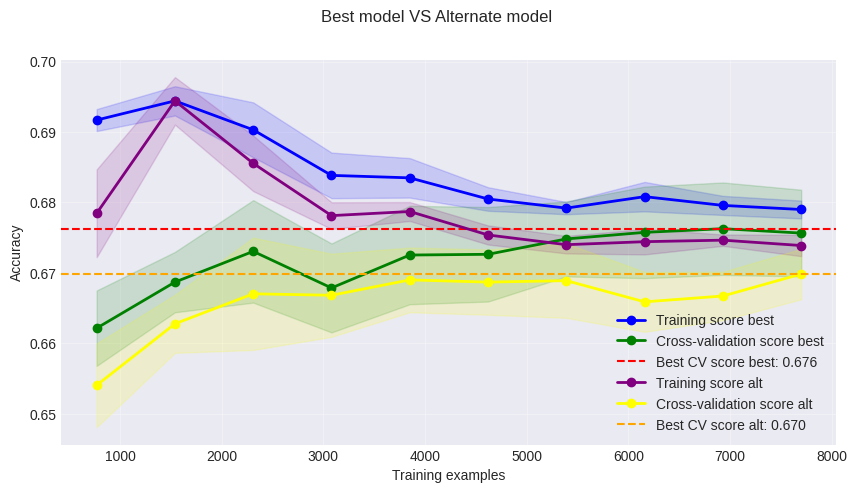

In [21]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*gender_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_gender_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Для сравнения использовались 2 конфигурации:
- Конфигурация с лучшим счетом по GS
- Конфигурация с регуляризацией через меньшее кол-во признаков

Как видно по графику обучения, обе конфигурации видут себя схожим образом. Определенный уровень сигнала из данных определяется уже на 10% выборки, а дальше происходит "незначительное" улучшение качества, если это можно так назвать.

Лучший показатель - 67,5%. L2-регуляризация со всеми признаками показывает чуть больше точность, чем регуляризация путем минимизации признаков

In [ ]:
gender_best_model.fit(train, train['gender'])
save(
    gender_best_model, 
    "lr_gender_best", 
    gender_best_model_params, 
    { "val": gender_best_model_iter_learning_score[2].tolist(), "train": gender_best_model_iter_learning_score[1].tolist() }
)

### Классификатор возраста

In [23]:
age_pipeline = create_lr_pipeline()

age_gs = grid_search(age_pipeline, pipeline_params, train, train['age'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [24]:
age_gs.best_params_, age_gs.best_score_

({'model__C': 0.1,
  'model__penalty': 'l1',
  'model__random_state': 42,
  'model__solver': 'liblinear',
  'scale_and_select__numeric__select_kbest__k': 10},
 np.float64(0.620051948051948))

In [25]:
age_top_5_info = get_top_n_info(age_gs, n=5)
age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__random_state,param_model__solver,param_scale_and_select__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
24,0.775320,0.047686,0.015134,0.001096,0.1,l1,42,liblinear,10,"{'model__C': 0.1, 'model__penalty': 'l1', 'mod...",0.597922,0.632727,0.617662,0.624416,0.627532,0.620052,0.012092,1
60,1.134315,0.140532,0.018633,0.003779,5.0,l1,42,liblinear,10,"{'model__C': 5, 'model__penalty': 'l1', 'model...",0.598442,0.631169,0.623896,0.620260,0.625974,0.619948,0.011318,2
54,1.183560,0.051399,0.021300,0.001872,1.0,l2,42,liblinear,10,"{'model__C': 1, 'model__penalty': 'l2', 'model...",0.598442,0.631169,0.623896,0.620779,0.624416,0.619740,0.011175,3
42,1.104684,0.072836,0.023844,0.001657,0.5,l2,42,liblinear,10,"{'model__C': 0.5, 'model__penalty': 'l2', 'mod...",0.597403,0.630649,0.624416,0.620260,0.625455,0.619636,0.011599,4
114,1.259950,0.063579,0.026142,0.004649,100.0,l2,42,liblinear,10,"{'model__C': 100, 'model__penalty': 'l2', 'mod...",0.597403,0.631688,0.622857,0.620779,0.624935,0.619532,0.011656,5


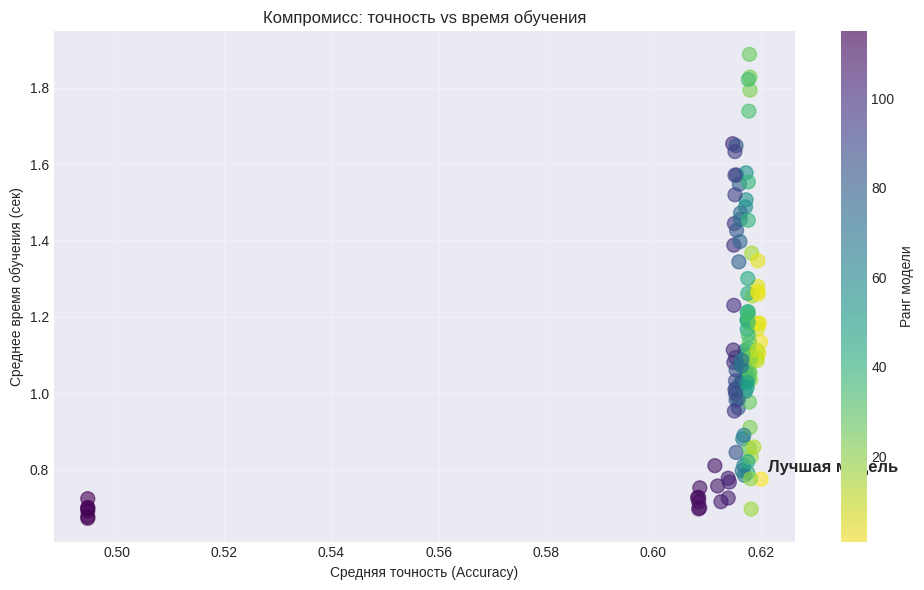

In [26]:
plot_complexity_and_accuracy(age_gs)

In [28]:
age_best_model_params = {
  'model__C': 0.1,
  'model__penalty': 'l1',
  'model__random_state': 42,
  'model__solver': 'liblinear',
  'scale_and_select__numeric__select_kbest__k': 10
}

age_best_model = create_lr_pipeline()
age_best_model.set_params(**age_best_model_params)
age_best_model_iter_learning_score = iteration_learning_score(age_best_model, train, train['age'])

In [33]:
alt_age_model = create_lr_pipeline()
alt_age_model.set_params(**
{
    'model__C': 0.1,                 
    'model__penalty': 'l1',          
    'model__random_state': 42,        
    'model__solver': 'liblinear',     
    'scale_and_select__numeric__select_kbest__k': 'all'
}
)
alt_age_model_iter_learning_score = iteration_learning_score(alt_age_model, train, train['age'])

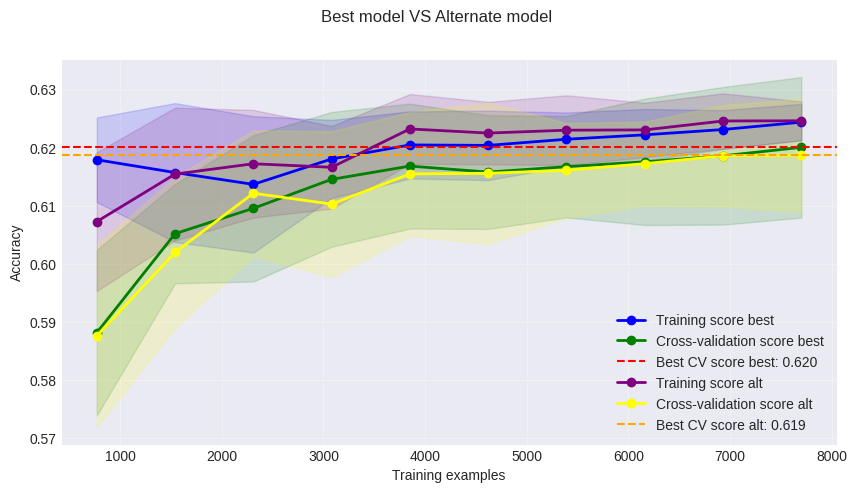

In [34]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Найденная через GS конфигурация использует KBest-отбор с 10 признаками. Альтернативная конфигурация без отбора (k=all) показывает на 0.1% результат хуже. 
Отбор 10 лучших признаков даёт практически такое же качество, как и все признаки, значит остальные непрерывные признаки не добавляют полезной информации

Лучшая точнсть - 62%. 

In [35]:
age_best_model.fit(train, train['age'])
save(
    age_best_model, 
    "lr_age_best", 
    age_best_model_params, 
    { "val": age_best_model_iter_learning_score[2].tolist(), "train": age_best_model_iter_learning_score[1].tolist() }
)

## Каскадный подход

Прогнозирование пола показывает более высокий показатель точности, по сравнению с прогнозирование возрастной группы. По этой причине сначала будет прогнозироваться пол, а затем в рамках пола - возраст

### Прогнозирование возраста мужчин

In [36]:
man_age_pipeline = create_lr_pipeline()

men_train = train[train['gender'] == 1]

men_age_gs = grid_search(man_age_pipeline, pipeline_params, men_train, men_train['age'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [37]:
men_age_gs.best_params_, men_age_gs.best_score_

({'model__C': 0.01,
  'model__penalty': 'l2',
  'model__random_state': 42,
  'model__solver': 'liblinear',
  'scale_and_select__numeric__select_kbest__k': 21},
 np.float64(0.6397071518571171))

In [38]:
men_age_top_5_info = get_top_n_info(men_age_gs, n=5)
men_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__random_state,param_model__solver,param_scale_and_select__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
22,0.549758,0.030158,0.014351,0.000527,0.01,l2,42,liblinear,21,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.633142,0.643678,0.650383,0.633749,0.637584,0.639707,0.006525,1
23,0.555364,0.029520,0.013896,0.000619,0.01,l2,42,liblinear,all,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.632184,0.643678,0.643678,0.634708,0.641419,0.639133,0.004784,2
30,0.575634,0.032730,0.014102,0.000169,0.10,l2,42,liblinear,10,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.636973,0.648467,0.638889,0.626079,0.627037,0.635489,0.008273,3
32,0.579949,0.045156,0.015576,0.001769,0.10,l2,42,liblinear,16,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.638889,0.641762,0.642720,0.622244,0.630872,0.635298,0.007743,4
18,0.539733,0.021651,0.014383,0.001185,0.01,l2,42,liblinear,10,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.633142,0.640805,0.643678,0.627996,0.629914,0.635107,0.006121,5


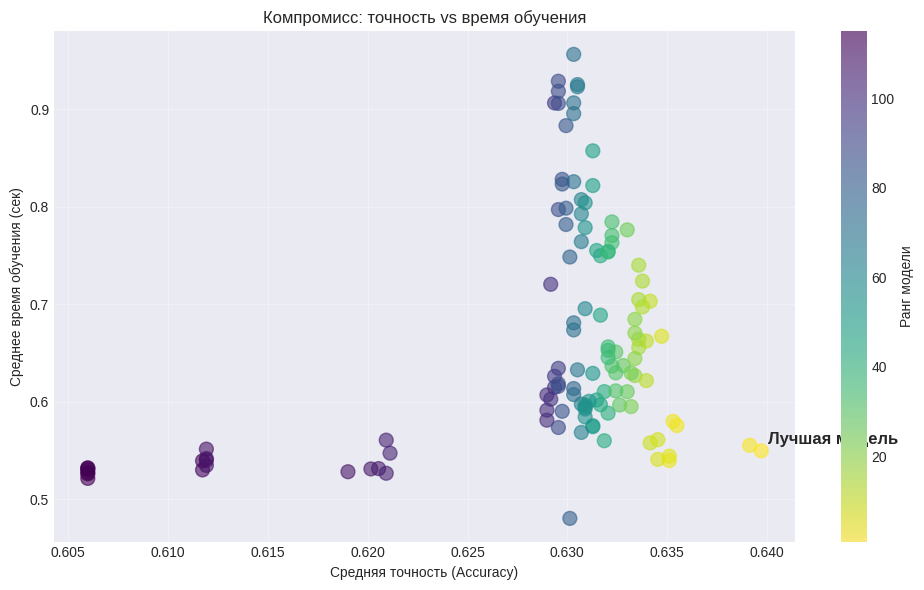

In [39]:
plot_complexity_and_accuracy(men_age_gs)

In [40]:
men_age_best_model_params = {
    'model__C': 0.01,
    'model__penalty': 'l2',
    'model__random_state': 42,
    'model__solver': 'liblinear',
    'scale_and_select__numeric__select_kbest__k': 21
}
men_age_best_model = create_lr_pipeline()
men_age_best_model.set_params(**men_age_best_model_params)
men_age_best_model_iter_learning_score = iteration_learning_score(men_age_best_model, men_train, men_train['age'])

In [43]:
alt_men_age_model = create_lr_pipeline()
alt_men_age_model.set_params(**
{
    'model__C': 0.1,                 
    'model__penalty': 'l2',          
    'model__random_state': 42,        
    'model__solver': 'liblinear',     
    'scale_and_select__numeric__select_kbest__k': 'all'
}
)
alt_men_age_model_iter_learning_score = iteration_learning_score(alt_men_age_model, men_train, men_train['age'])

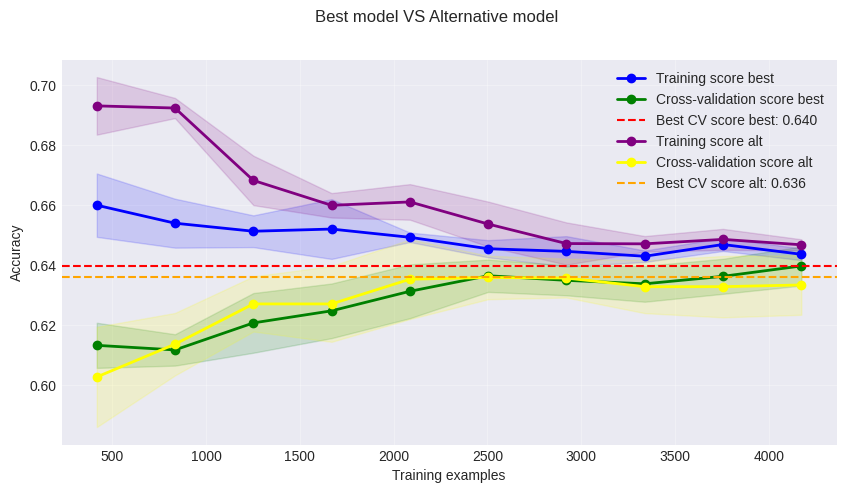

In [44]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*men_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_men_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Определение возраста в мужской подвыборке имеет точность на 2%, относительно общей модели

In [45]:
men_age_best_model.fit(men_train, men_train['age'])
save(
    men_age_best_model, 
    "lr_men_age_best", 
    men_age_best_model_params, 
    { "val": men_age_best_model_iter_learning_score[2].tolist(), "train": men_age_best_model_iter_learning_score[1].tolist() }
)

### Прогнозирование возраста женщин

In [46]:
woman_age_pipeline = create_lr_pipeline()

women_train = train[train['gender'] == 0]

women_age_gs = grid_search(woman_age_pipeline, pipeline_params, women_train, women_train['age'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [47]:
women_age_gs.best_params_, women_age_gs.best_score_

({'model__C': 0.5,
  'model__penalty': 'l1',
  'model__random_state': 42,
  'model__solver': 'liblinear',
  'scale_and_select__numeric__select_kbest__k': 16},
 np.float64(0.6675829620535312))

In [48]:
women_age_top_5_info = get_top_n_info(women_age_gs, n=5)
women_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__random_state,param_model__solver,param_scale_and_select__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
38,0.694919,0.065472,0.015232,0.000617,0.5,l1,42,liblinear,16,"{'model__C': 0.5, 'model__penalty': 'l1', 'mod...",0.642857,0.654195,0.686720,0.690125,0.664018,0.667583,0.018318,1
52,0.842641,0.046141,0.016823,0.003422,1.0,l1,42,liblinear,21,"{'model__C': 1, 'model__penalty': 'l1', 'model...",0.642857,0.656463,0.685585,0.692395,0.660613,0.667582,0.018565,2
51,0.802706,0.045918,0.016111,0.001886,1.0,l1,42,liblinear,18,"{'model__C': 1, 'model__penalty': 'l1', 'model...",0.640590,0.653061,0.681044,0.692395,0.668558,0.667130,0.018635,3
62,0.811851,0.031597,0.015312,0.001253,5.0,l1,42,liblinear,16,"{'model__C': 5, 'model__penalty': 'l1', 'model...",0.645125,0.659864,0.681044,0.685585,0.664018,0.667127,0.014703,4
42,0.572594,0.018226,0.013907,0.001304,0.5,l2,42,liblinear,10,"{'model__C': 0.5, 'model__penalty': 'l2', 'mod...",0.641723,0.655329,0.683314,0.685585,0.668558,0.666902,0.016668,5


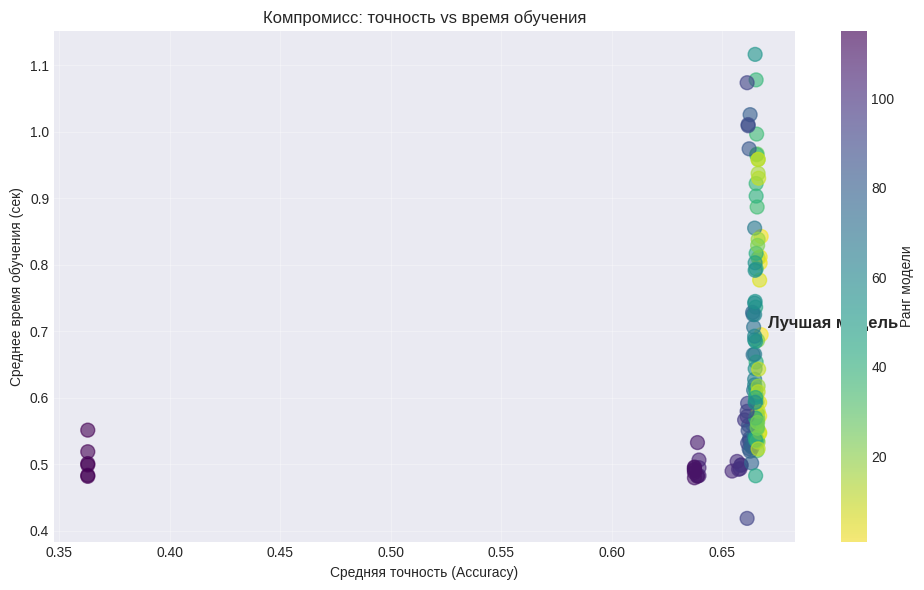

In [49]:
plot_complexity_and_accuracy(women_age_gs)

In [50]:
women_age_best_model_params = { 
    'model__C': 0.5,
    'model__penalty': 'l1',
    'model__random_state': 42,
    'model__solver': 'liblinear',
    'scale_and_select__numeric__select_kbest__k': 16
}
women_age_best_model = create_lr_pipeline()
women_age_best_model.set_params(**women_age_best_model_params)
women_age_best_model_iter_learning_score = iteration_learning_score(women_age_best_model, women_train, women_train['age'])

In [53]:
alt_women_age_model = create_lr_pipeline()
alt_women_age_model.set_params(**
{
    'model__C': 0.5,                 
    'model__penalty': 'l1',          
    'model__random_state': 42,        
    'model__solver': 'liblinear',     
    'scale_and_select__numeric__select_kbest__k': 'all'
}
)
alt_women_age_model_iter_learning_score = iteration_learning_score(alt_women_age_model, women_train, women_train['age'])

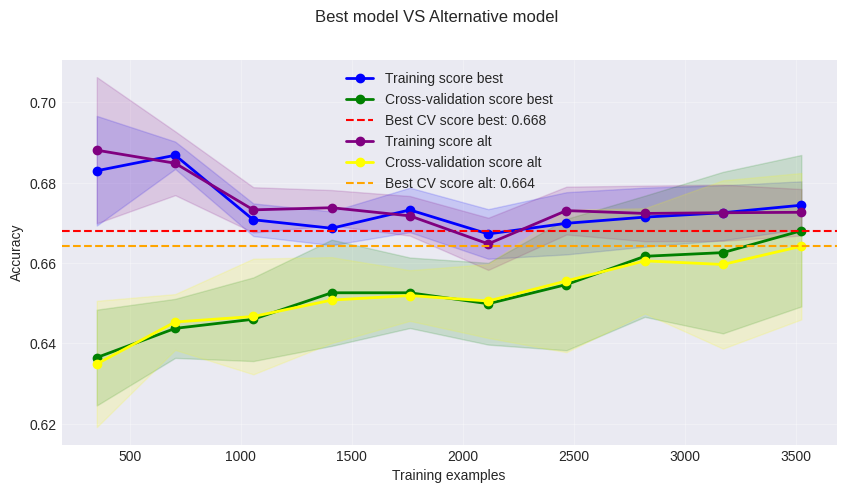

In [54]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*women_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_women_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Использование каскадного подхода позволило слегка улучшить качество прогнозирования с 62% до 64%-67%. Каждая модель стала лучше разбираться в рамках своего пола

In [55]:
women_age_best_model.fit(women_train, women_train['age'])
save(
    women_age_best_model, 
    "lr_women_age_best", 
    women_age_best_model_params, 
    { "val": women_age_best_model_iter_learning_score[2].tolist(), "train": women_age_best_model_iter_learning_score[1].tolist() }
)

## Плоский подход

In [56]:
flat_y_train = train['gender'] * 2 + train['age']

In [58]:
flat_pipeline = create_lr_pipeline()

flat_gs = grid_search(flat_pipeline, pipeline_params | { 'model__solver': ['lbfgs'] }, train, flat_y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [59]:
flat_gs.best_params_, flat_gs.best_score_

({'model__C': 50,
  'model__penalty': 'l2',
  'model__random_state': 42,
  'model__solver': 'lbfgs',
  'scale_and_select__numeric__select_kbest__k': 16},
 np.float64(0.45371428571428574))

In [60]:
flat_top_5_info = get_top_n_info(flat_gs, n=5)
flat_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__penalty,param_model__random_state,param_model__solver,param_scale_and_select__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
104,0.983730,0.055634,0.018854,0.001321,50.0,l2,42,lbfgs,16,"{'model__C': 50, 'model__penalty': 'l2', 'mode...",0.443636,0.454026,0.454545,0.461818,0.454545,0.453714,0.005809,1
116,0.949287,0.028187,0.017508,0.000715,100.0,l2,42,lbfgs,16,"{'model__C': 100, 'model__penalty': 'l2', 'mod...",0.443117,0.454026,0.452987,0.462338,0.453506,0.453195,0.006099,2
119,0.795350,0.074779,0.009484,0.001429,100.0,l2,42,lbfgs,all,"{'model__C': 100, 'model__penalty': 'l2', 'mod...",0.446234,0.449870,0.455065,0.458701,0.456104,0.453195,0.004512,2
32,0.935422,0.063868,0.018378,0.001071,0.1,l2,42,lbfgs,16,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.444675,0.453506,0.452468,0.461818,0.452468,0.452987,0.005438,4
80,0.939577,0.035836,0.018094,0.001645,10.0,l2,42,lbfgs,16,"{'model__C': 10, 'model__penalty': 'l2', 'mode...",0.443117,0.453506,0.452468,0.462338,0.453506,0.452987,0.006094,4


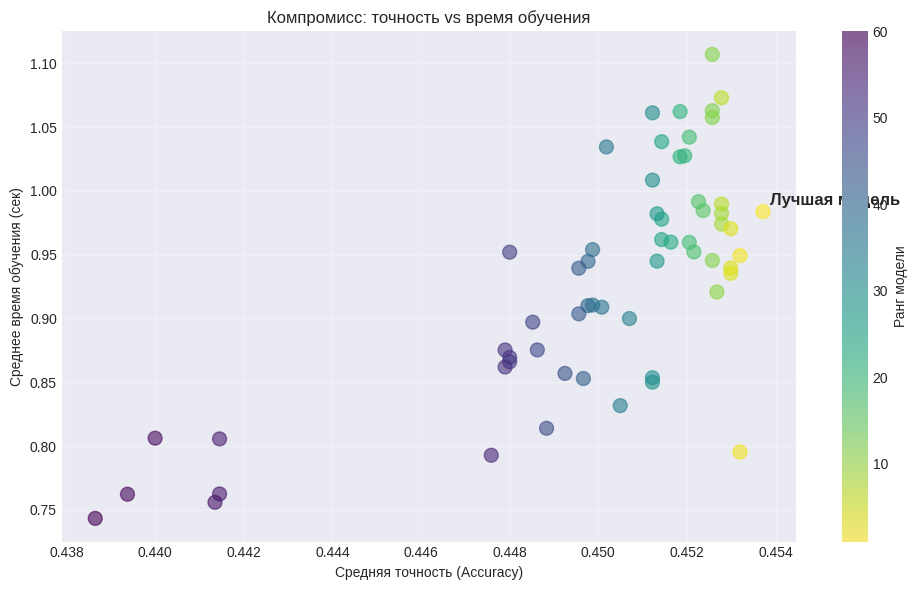

In [61]:
plot_complexity_and_accuracy(flat_gs)

In [62]:
flat_best_model_params = {
    'model__C': 50,
    'model__penalty': 'l2',
    'model__random_state': 42,
    'model__solver': 'lbfgs',
    'scale_and_select__numeric__select_kbest__k': 16
}
flat_best_model = create_lr_pipeline()
flat_best_model.set_params(**flat_best_model_params)
flat_best_model_iter_learning_score = iteration_learning_score(flat_best_model, train, flat_y_train)

In [64]:
flat_alt_model = create_lr_pipeline()
flat_alt_model.set_params(**{
    'model__C': 50,
    'model__penalty': 'l2',
    'model__random_state': 42,
    'model__solver': 'lbfgs',
    'scale_and_select__numeric__select_kbest__k': 'all'
})
flat_alt_model_iter_learning_score = iteration_learning_score(flat_alt_model, train, flat_y_train)

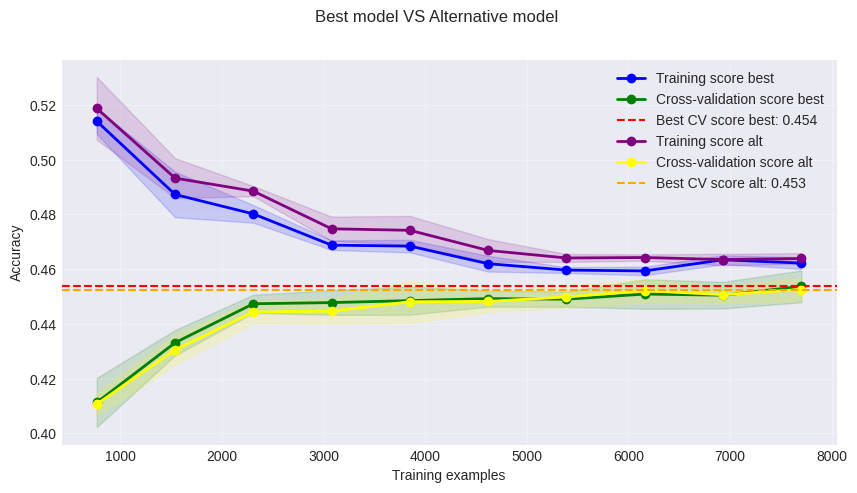

In [65]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*flat_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*flat_alt_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Точность каскадного подхода приблизительно составит `0.676 * 0.640 = 0.433`. Плоский подход превосходит эту приблизительную точность на 2% процента.

In [66]:
flat_best_model.fit(train, flat_y_train)
save(
    flat_best_model, 
    "lr_flat_best", 
    flat_best_model_params, 
    { "val": flat_best_model_iter_learning_score[2].tolist(), "train": flat_best_model_iter_learning_score[1].tolist() }
)